In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn plotly statsmodels

In [2]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.1 MB/s eta 0:00:00


In [6]:
import os
print(os.listdir())

['.config', 'sample_data']


In [8]:
from google.colab import files
uploaded = files.upload()

Saving GlobalLandTemperaturesByCity.csv to GlobalLandTemperaturesByCity.csv


In [10]:
import pandas as pd

df = pd.read_csv('GlobalLandTemperaturesByCity.csv')
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [11]:
import os

os.makedirs('data/raw', exist_ok=True)

In [12]:
import shutil
shutil.move('GlobalLandTemperaturesByCity.csv', 'data/raw/')

'data/raw/GlobalLandTemperaturesByCity.csv'

In [13]:
df = pd.read_csv('data/raw/GlobalLandTemperaturesByCity.csv')

In [14]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   dt                             object 
 1   AverageTemperature             float64
 2   AverageTemperatureUncertainty  float64
 3   City                           object 
 4   Country                        object 
 5   Latitude                       object 
 6   Longitude                      object 
dtypes: float64(2), object(5)
memory usage: 459.2+ MB


In [16]:
df.isnull().sum()

,0
dt,0
AverageTemperature,364130
AverageTemperatureUncertainty,364130
City,0
Country,0
Latitude,0
Longitude,0


In [17]:
df = df.dropna(subset=['AverageTemperature'])

In [18]:
df['dt'] = pd.to_datetime(df['dt'])

In [19]:
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month

In [20]:
df = df[df['year'] > 1900]

In [21]:
df.head()
df.describe()

,dt,AverageTemperature,AverageTemperatureUncertainty,year,month
count,4745960,4.745960e+06,4.745960e+06,4.745960e+06,4.745960e+06
mean,1957-04-18 08:49:23.281611776,1.783087e+01,4.403416e-01,1.956840e+03,6.488399e+00
min,1901-01-01 00:00:00,-4.270400e+01,3.400000e-02,1.901000e+03,1.000000e+00
25%,1929-03-01 00:00:00,1.207400e+01,2.680000e-01,1.929000e+03,3.000000e+00
50%,1957-05-01 00:00:00,2.020800e+01,3.710000e-01,1.957000e+03,6.000000e+00
75%,1985-07-01 00:00:00,2.580500e+01,5.310000e-01,1.985000e+03,9.000000e+00
max,2013-09-01 00:00:00,3.915600e+01,7.568000e+00,2.013000e+03,1.200000e+01
std,NaN,1.003263e+01,2.679358e-01,3.252748e+01,3.449671e+00


In [22]:
df.head()
df.describe()

,dt,AverageTemperature,AverageTemperatureUncertainty,year,month
count,4745960,4.745960e+06,4.745960e+06,4.745960e+06,4.745960e+06
mean,1957-04-18 08:49:23.281611776,1.783087e+01,4.403416e-01,1.956840e+03,6.488399e+00
min,1901-01-01 00:00:00,-4.270400e+01,3.400000e-02,1.901000e+03,1.000000e+00
25%,1929-03-01 00:00:00,1.207400e+01,2.680000e-01,1.929000e+03,3.000000e+00
50%,1957-05-01 00:00:00,2.020800e+01,3.710000e-01,1.957000e+03,6.000000e+00
75%,1985-07-01 00:00:00,2.580500e+01,5.310000e-01,1.985000e+03,9.000000e+00
max,2013-09-01 00:00:00,3.915600e+01,7.568000e+00,2.013000e+03,1.200000e+01
std,NaN,1.003263e+01,2.679358e-01,3.252748e+01,3.449671e+00


In [23]:
yearly_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()

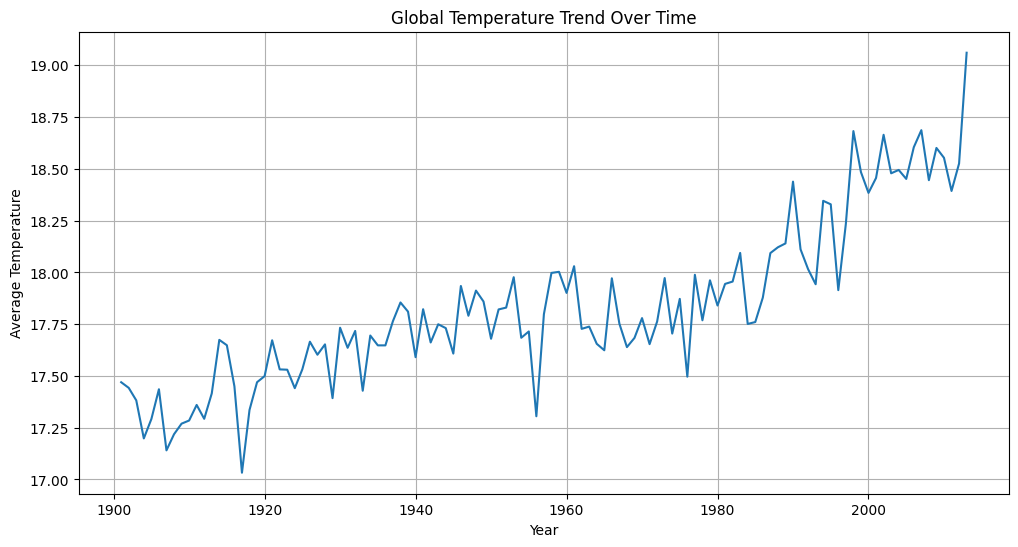

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
plt.title("Global Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.grid(True)
plt.show()

In [27]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

In [28]:
from google.colab import files
files.download('outputs/plots/temp_trend.png')

FileNotFoundError: Cannot find file: outputs/plots/temp_trend.png

In [30]:
import os
os.makedirs("outputs/plots", exist_ok=True)

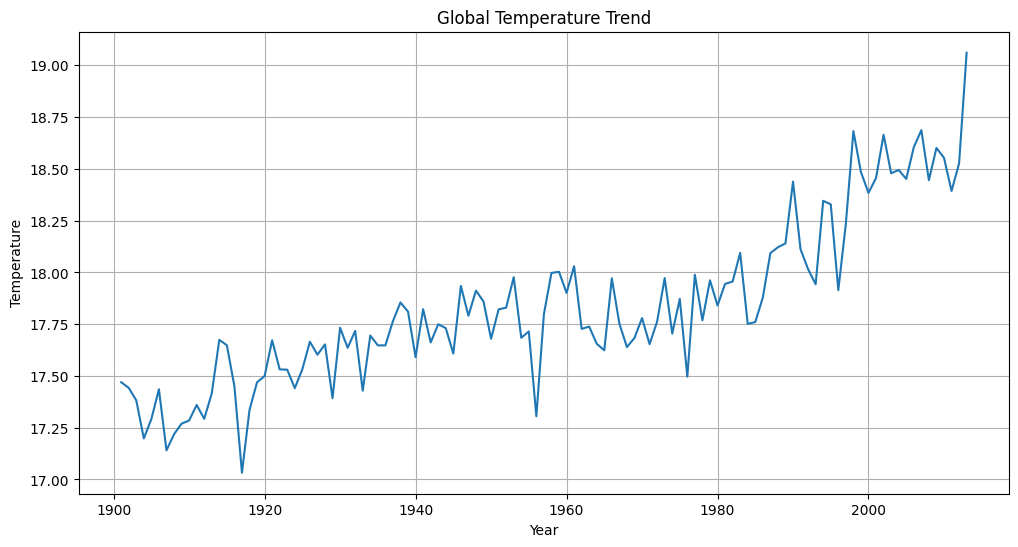

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])

plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid(True)

# IMPORTANT: Save BEFORE show
plt.savefig("outputs/plots/temp_trend.png")

plt.show()

In [32]:
import os
print(os.listdir("outputs/plots"))

['temp_trend.png']


In [33]:
from google.colab import files
files.download('outputs/plots/temp_trend.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import os

print("Folders:", os.listdir())
print("Outputs:", os.listdir("outputs") if "outputs" in os.listdir() else "No outputs folder")
print("Plots:", os.listdir("outputs/plots") if "outputs" in os.listdir() else "No plots")

Folders: ['.config', 'outputs', 'temp_trend.png', 'data', 'sample_data']
Outputs: ['plots']
Plots: ['temp_trend.png']


In [29]:
plt.savefig("temp_trend.png")

<Figure size 640x480 with 0 Axes>

In [35]:
# Calculate mean & std
mean_temp = yearly_temp['AverageTemperature'].mean()
std_temp = yearly_temp['AverageTemperature'].std()

# Define threshold
upper_limit = mean_temp + 2 * std_temp
lower_limit = mean_temp - 2 * std_temp

# Detect anomalies
anomalies = yearly_temp[
    (yearly_temp['AverageTemperature'] > upper_limit) |
    (yearly_temp['AverageTemperature'] < lower_limit)
]

print(anomalies)

     year  AverageTemperature
16   1917           17.032359
97   1998           18.682514
101  2002           18.664708
106  2007           18.686941
112  2013           19.061038


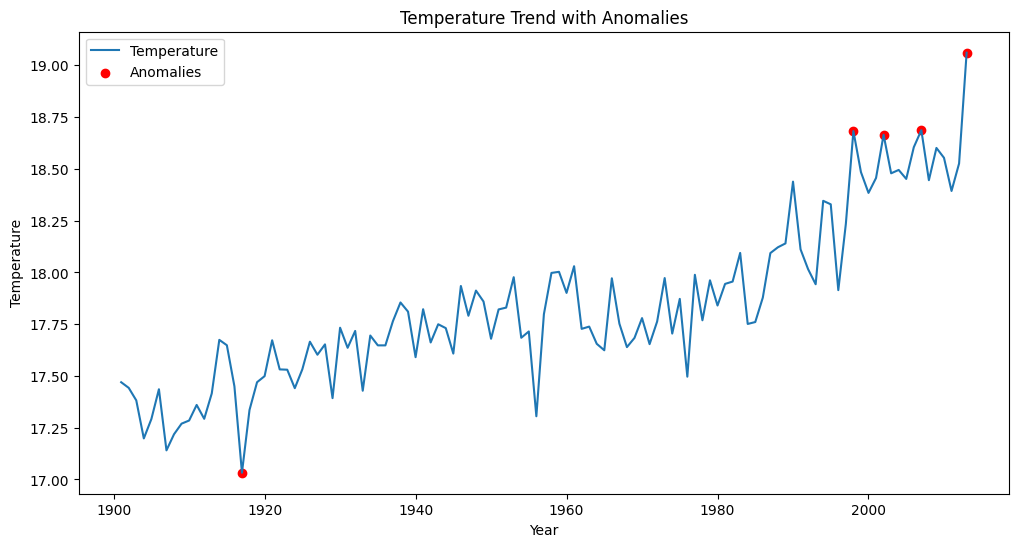

In [36]:
plt.figure(figsize=(12,6))

# Normal data
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], label='Temperature')

# Highlight anomalies
plt.scatter(anomalies['year'], anomalies['AverageTemperature'], color='red', label='Anomalies')

plt.title("Temperature Trend with Anomalies")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.legend()

# Save
plt.savefig("outputs/plots/anomaly_plot.png")

plt.show()

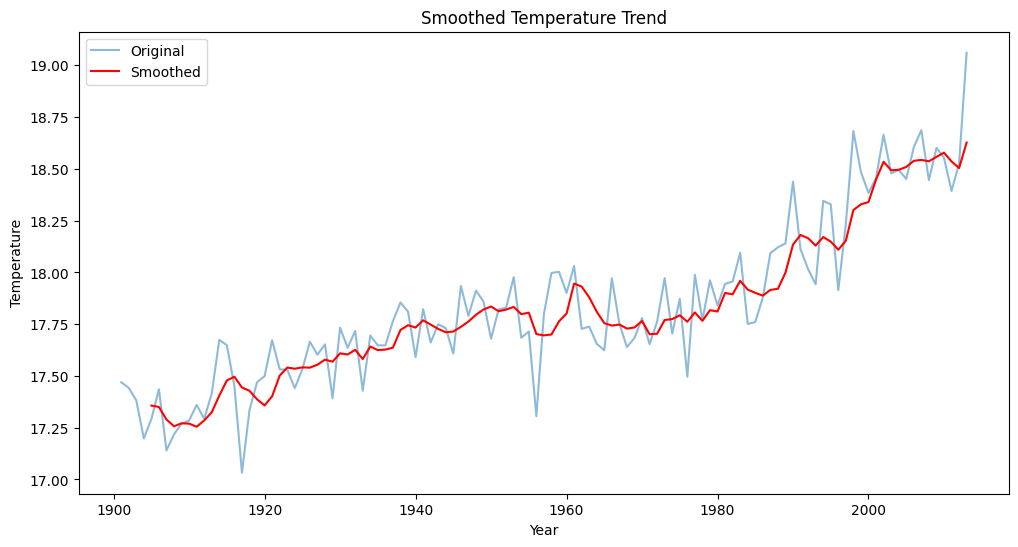

In [37]:
yearly_temp['RollingAvg'] = yearly_temp['AverageTemperature'].rolling(window=5).mean()

plt.figure(figsize=(12,6))

plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], alpha=0.5, label='Original')
plt.plot(yearly_temp['year'], yearly_temp['RollingAvg'], color='red', label='Smoothed')

plt.title("Smoothed Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.legend()

plt.savefig("outputs/plots/rolling_avg.png")

plt.show()

In [38]:
from statsmodels.tsa.arima.model import ARIMA

# Train model
model = ARIMA(yearly_temp['AverageTemperature'], order=(2,1,2))
model_fit = model.fit()

# Forecast next 10 years
forecast = model_fit.forecast(steps=10)

print(forecast)

113    18.732788
114    18.698169
115    18.676585
116    18.684837
117    18.677237
118    18.682753
119    18.678544
120    18.681719
121    18.679317
122    18.681133
Name: predicted_mean, dtype: float64


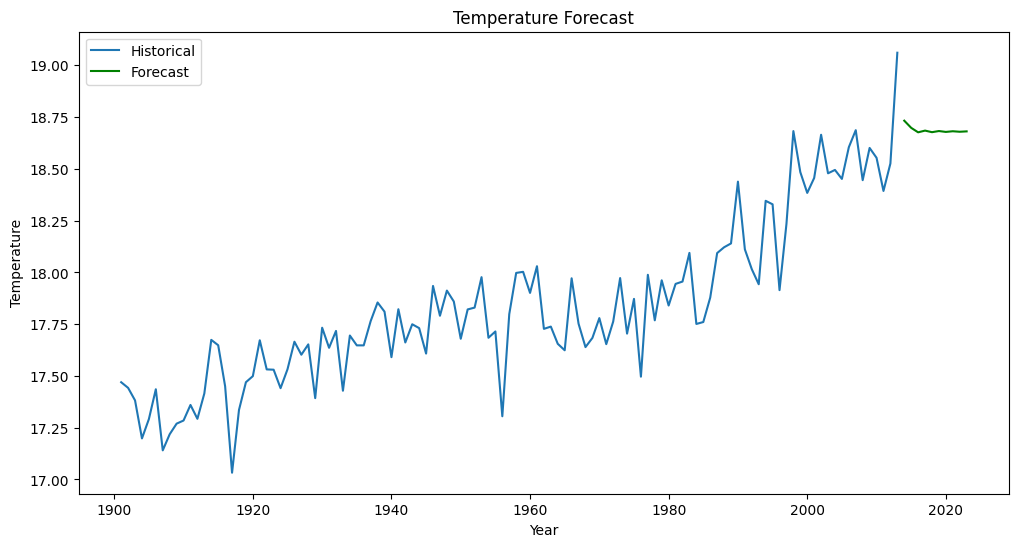

In [39]:
import numpy as np

future_years = np.arange(yearly_temp['year'].max()+1, yearly_temp['year'].max()+11)

plt.figure(figsize=(12,6))

plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], label='Historical')
plt.plot(future_years, forecast, color='green', label='Forecast')

plt.title("Temperature Forecast")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.legend()

plt.savefig("outputs/plots/forecast.png")

plt.show()

In [40]:
# Load
import pandas as pd
df = pd.read_csv('GlobalLandTemperaturesByCity.csv')

# Clean
df = df.dropna(subset=['AverageTemperature'])
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year
df = df[df['year'] > 1900]

# Trend
yearly_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()

# Plot
import matplotlib.pyplot as plt
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
plt.savefig("outputs/plots/temp_trend.png")
plt.show()

# Anomaly
mean = yearly_temp['AverageTemperature'].mean()
std = yearly_temp['AverageTemperature'].std()

anomalies = yearly_temp[
    (yearly_temp['AverageTemperature'] > mean + 2*std) |
    (yearly_temp['AverageTemperature'] < mean - 2*std)
]

# Forecast
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(yearly_temp['AverageTemperature'], order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=10)

FileNotFoundError: [Errno 2] No such file or directory: 'GlobalLandTemperaturesByCity.csv'

In [41]:
df = pd.read_csv('GlobalLandTemperaturesByCity.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'GlobalLandTemperaturesByCity.csv'

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import os
os.listdir('/content/drive/MyDrive')

['phy_428x240_256x144.mp4',
 'Bootstrap template ',
 'Testimonial ',
 'Integrated Retail Analytics for Store Optimization',
 "2025-09-18 16.53.49 Jatin Gujarathi's Zoom Meeting",
 'Tourism_Analytics_Project',
 'Exploratory video for Amazon Delivery Time Prediction',
 "2025-09-26 12.50.53 Jatin Gujarathi's Zoom Meeting",
 'Amazon Delivery time prediction',
 'aic=10, cls=0.5, compile=False, conf=None, copy_p....gsheet',
 'agnostic_nms=False, amp=True, augment=False, auto....gsheet',
 'nostic_nms=False, amp=True, augment=False, auto_a....gsheet',
 'Real Estate Investment Advisor Predicting Property Profitability & Future Value',
 'Real Estate Investment Advisor Predicting Property Profitability & Future explanatory video',
 'Jalna Hospitals Contact Information.gsheet',
 'Jalna Private Hospitals Directory Update.gsheet',
 'Chhatrapati Sambhajinagar Hotel Contacts.gsheet',
 'Aurangabad Hotel Contact Information (2).gsheet',
 'Aurangabad Hotel Contact Information (1).gsheet',
 'Hotel List fo

In [44]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv')
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [45]:
# Clean data
df = df.dropna(subset=['AverageTemperature'])

# Convert date
df['dt'] = pd.to_datetime(df['dt'])

# Extract year & month
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month

# Filter modern data
df = df[df['year'] > 1900]

df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year,month
1886,1901-01-01,-1.507,0.660,Århus,Denmark,57.05N,10.33E,1901,1
1887,1901-02-01,-2.406,0.783,Århus,Denmark,57.05N,10.33E,1901,2
1888,1901-03-01,1.224,0.285,Århus,Denmark,57.05N,10.33E,1901,3
1889,1901-04-01,6.261,0.505,Århus,Denmark,57.05N,10.33E,1901,4
1890,1901-05-01,12.181,0.438,Århus,Denmark,57.05N,10.33E,1901,5


In [46]:
yearly_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()
yearly_temp.head()

,year,AverageTemperature
0,1901,17.469447
1,1902,17.442242
2,1903,17.381779
3,1904,17.198060
4,1905,17.291567


In [47]:
import os
os.makedirs("outputs/plots", exist_ok=True)

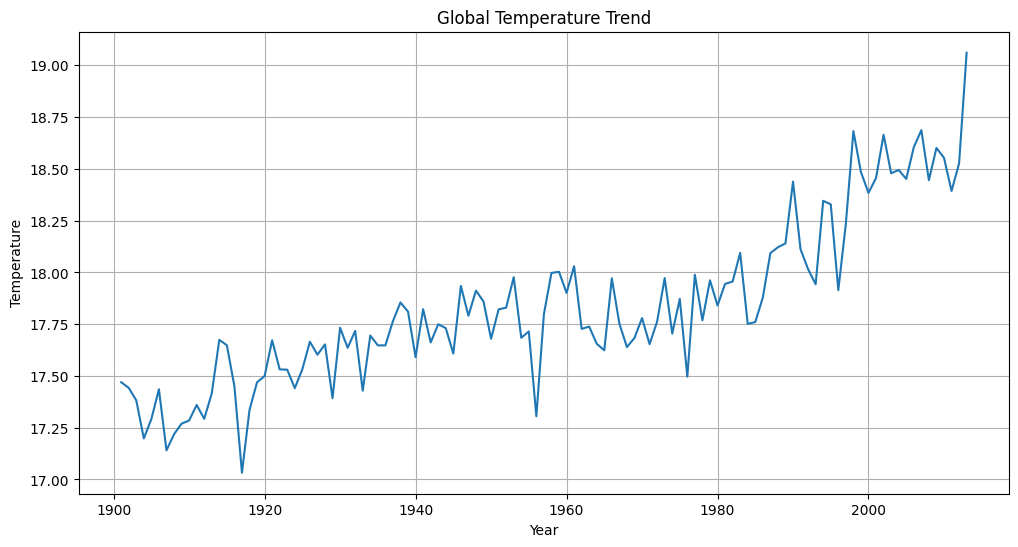

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])

plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid(True)

plt.savefig("outputs/plots/temp_trend.png")
plt.show()


In [49]:
mean = yearly_temp['AverageTemperature'].mean()
std = yearly_temp['AverageTemperature'].std()

anomalies = yearly_temp[
    (yearly_temp['AverageTemperature'] > mean + 2*std) |
    (yearly_temp['AverageTemperature'] < mean - 2*std)
]

print(anomalies)

     year  AverageTemperature
16   1917           17.032359
97   1998           18.682514
101  2002           18.664708
106  2007           18.686941
112  2013           19.061038


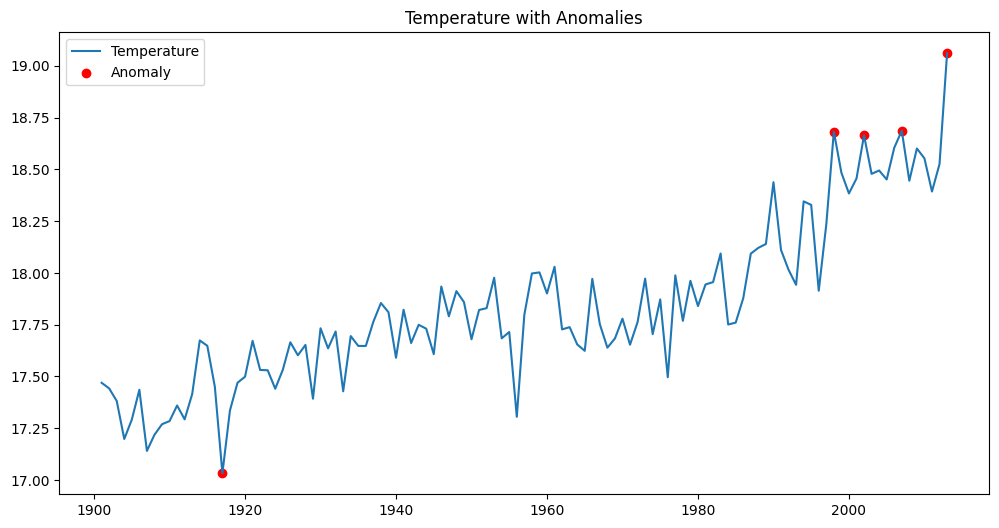

In [50]:
plt.figure(figsize=(12,6))

plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], label='Temperature')
plt.scatter(anomalies['year'], anomalies['AverageTemperature'], color='red', label='Anomaly')

plt.title("Temperature with Anomalies")
plt.legend()

plt.savefig("outputs/plots/anomaly_plot.png")
plt.show()

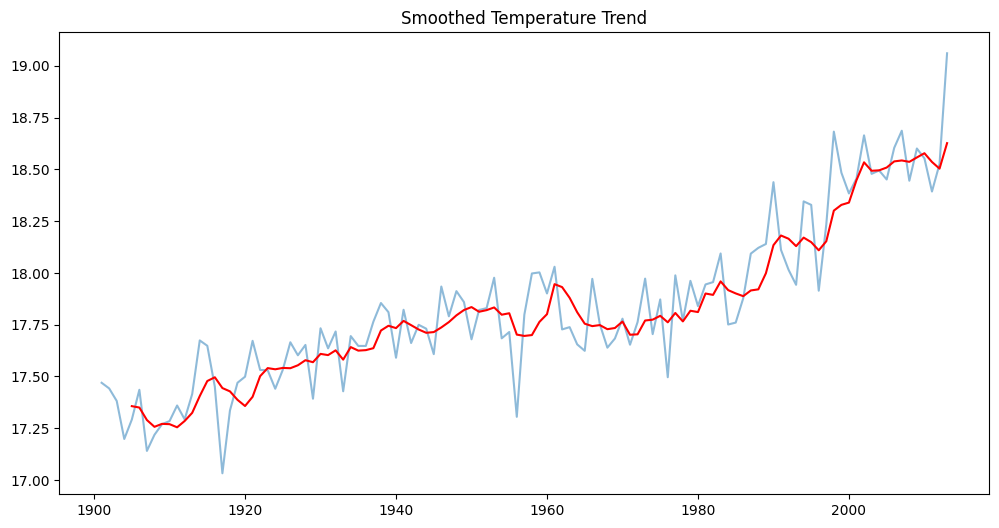

In [51]:
yearly_temp['RollingAvg'] = yearly_temp['AverageTemperature'].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], alpha=0.5)
plt.plot(yearly_temp['year'], yearly_temp['RollingAvg'], color='red')

plt.title("Smoothed Temperature Trend")

plt.savefig("outputs/plots/rolling_avg.png")
plt.show()

In [52]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(yearly_temp['AverageTemperature'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)
print(forecast)

113    18.732788
114    18.698169
115    18.676585
116    18.684837
117    18.677237
118    18.682753
119    18.678544
120    18.681719
121    18.679317
122    18.681133
Name: predicted_mean, dtype: float64


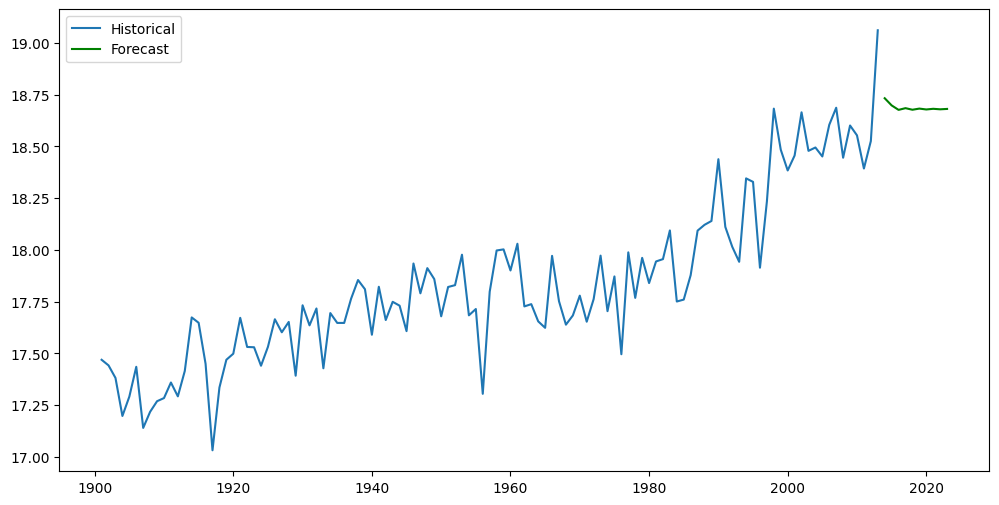

In [53]:
import numpy as np

future_years = np.arange(yearly_temp['year'].max()+1, yearly_temp['year'].max()+11)

plt.figure(figsize=(12,6))
plt.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], label='Historical')
plt.plot(future_years, forecast, color='green', label='Forecast')

plt.legend()

plt.savefig("outputs/plots/forecast.png")
plt.show()

In [54]:
from google.colab import files

files.download("outputs/plots/temp_trend.png")
files.download("outputs/plots/anomaly_plot.png")
files.download("outputs/plots/rolling_avg.png")
files.download("outputs/plots/forecast.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
!pip install streamlit

In [56]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

st.title("🌍 Climate Trend Analyzer Dashboard")

# Upload file
uploaded_file = st.file_uploader("Upload Climate Dataset (CSV)", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)

    # Preprocessing
    df = df.dropna(subset=['AverageTemperature'])
    df['dt'] = pd.to_datetime(df['dt'])
    df['year'] = df['dt'].dt.year
    df = df[df['year'] > 1900]

    yearly_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()

    st.subheader("📈 Temperature Trend")
    fig1, ax1 = plt.subplots()
    ax1.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
    st.pyplot(fig1)

    # Anomaly detection
    mean = yearly_temp['AverageTemperature'].mean()
    std = yearly_temp['AverageTemperature'].std()

    anomalies = yearly_temp[
        (yearly_temp['AverageTemperature'] > mean + 2*std) |
        (yearly_temp['AverageTemperature'] < mean - 2*std)
    ]

    st.subheader("🔍 Anomaly Detection")
    fig2, ax2 = plt.subplots()
    ax2.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
    ax2.scatter(anomalies['year'], anomalies['AverageTemperature'], color='red')
    st.pyplot(fig2)

    # Rolling average
    yearly_temp['RollingAvg'] = yearly_temp['AverageTemperature'].rolling(window=5).mean()

    st.subheader("📉 Smoothed Trend")
    fig3, ax3 = plt.subplots()
    ax3.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], alpha=0.5)
    ax3.plot(yearly_temp['year'], yearly_temp['RollingAvg'], color='red')
    st.pyplot(fig3)

    # Forecast
    model = ARIMA(yearly_temp['AverageTemperature'], order=(2,1,2))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=10)

    future_years = np.arange(yearly_temp['year'].max()+1, yearly_temp['year'].max()+11)

    st.subheader("🔮 Forecast")
    fig4, ax4 = plt.subplots()
    ax4.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
    ax4.plot(future_years, forecast, color='green')
    st.pyplot(fig4)

2026-04-17 05:36:35.316 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.516 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-17 05:36:35.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:36:35.525 Thread 'MainThread': mi

In [58]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://large-snails-sit.loca.lt
^C


In [59]:
!streamlit run app.py & npx localtunnel --port 8501

⠙Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://ninety-jobs-pick.loca.lt
^C


In [61]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [60]:
df = df.sample(50000)   # reduce size

In [62]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [63]:
!streamlit run app.py &>/dev/null &

In [64]:
%%writefile fast_app.py

Writing fast_app.py


In [65]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("🌍 Climate Trend Analyzer (Fast Dashboard)")

# Upload dataset
uploaded_file = st.file_uploader("Upload CSV File", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)

    # Clean data
    df = df.dropna(subset=['AverageTemperature'])
    df['dt'] = pd.to_datetime(df['dt'])
    df['year'] = df['dt'].dt.year

    # Reduce size (IMPORTANT FOR SPEED)
    df = df.sample(50000)

    yearly_temp = df.groupby('year')['AverageTemperature'].mean().reset_index()

    # 📈 Trend
    st.subheader("📈 Temperature Trend")
    fig1, ax1 = plt.subplots()
    ax1.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
    st.pyplot(fig1)

    # 🔍 Anomaly Detection
    mean = yearly_temp['AverageTemperature'].mean()
    std = yearly_temp['AverageTemperature'].std()

    anomalies = yearly_temp[
        (yearly_temp['AverageTemperature'] > mean + 2*std) |
        (yearly_temp['AverageTemperature'] < mean - 2*std)
    ]

    st.subheader("🔍 Anomaly Detection")
    fig2, ax2 = plt.subplots()
    ax2.plot(yearly_temp['year'], yearly_temp['AverageTemperature'])
    ax2.scatter(anomalies['year'], anomalies['AverageTemperature'])
    st.pyplot(fig2)

    # 📉 Rolling Average
    yearly_temp['RollingAvg'] = yearly_temp['AverageTemperature'].rolling(5).mean()

    st.subheader("📉 Smoothed Trend")
    fig3, ax3 = plt.subplots()
    ax3.plot(yearly_temp['year'], yearly_temp['AverageTemperature'], alpha=0.5)
    ax3.plot(yearly_temp['year'], yearly_temp['RollingAvg'])
    st.pyplot(fig3)

    st.success("Dashboard Loaded Successfully 🚀")

2026-04-17 05:48:51.975 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:48:51.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [66]:
!streamlit run fast_app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧your url is: https://ten-buses-sing.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.137.14:8501

  Stopping...
^C


In [69]:
uploaded_file = st.file_uploader("Upload CSV File", type="csv")

2026-04-17 05:55:12.824 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:55:12.825 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:55:12.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:55:12.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:55:12.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:55:12.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [71]:
df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv')

In [72]:
import streamlit as st
import pandas as pd

st.title("Climate Dashboard")

df = pd.read_csv('/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv')

st.write(df.head())

2026-04-17 05:57:10.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:57:10.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:57:10.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:57:29.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:57:29.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 05:57:29.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [73]:
!streamlit run fast_app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧⠇your url is: https://yellow-bushes-fetch.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.137.14:8501

  Stopping...
^C


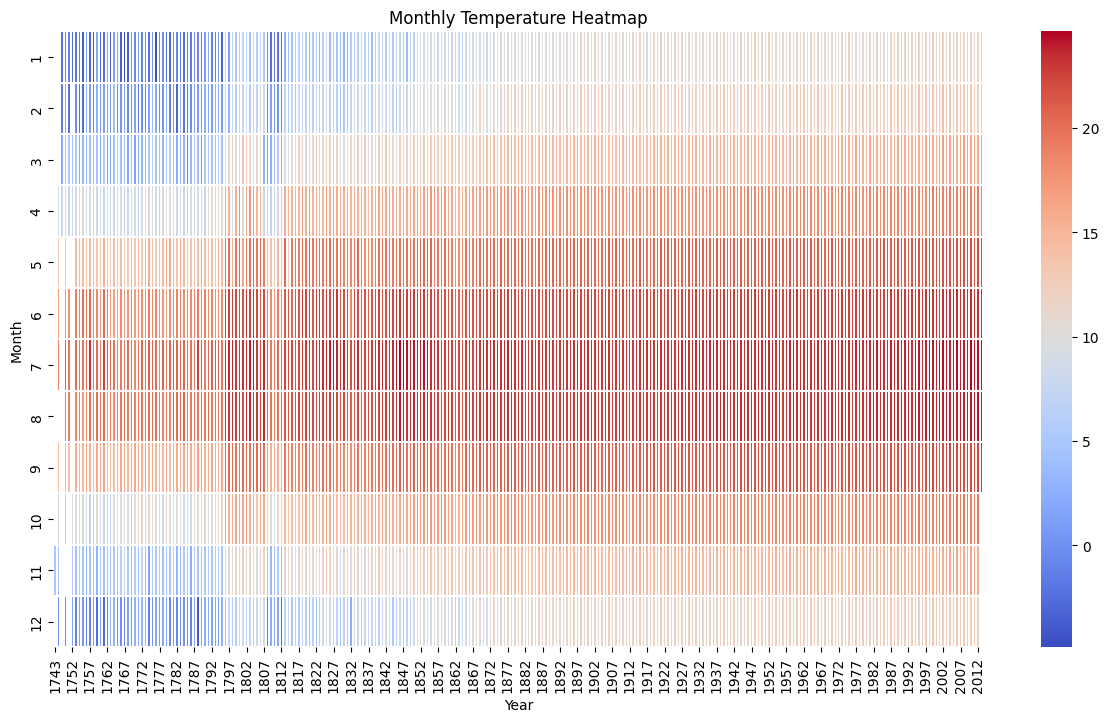

In [76]:
import seaborn as sns

# Create Year & Month
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month

# Pivot table
pivot = df.pivot_table(index='Month', columns='Year', values='AverageTemperature')

# Plot heatmap
plt.figure(figsize=(15,8))
sns.heatmap(pivot, cmap='coolwarm', linewidths=0.1)

plt.title("Monthly Temperature Heatmap")
plt.savefig("outputs/plots/heatmap.png")
plt.show()

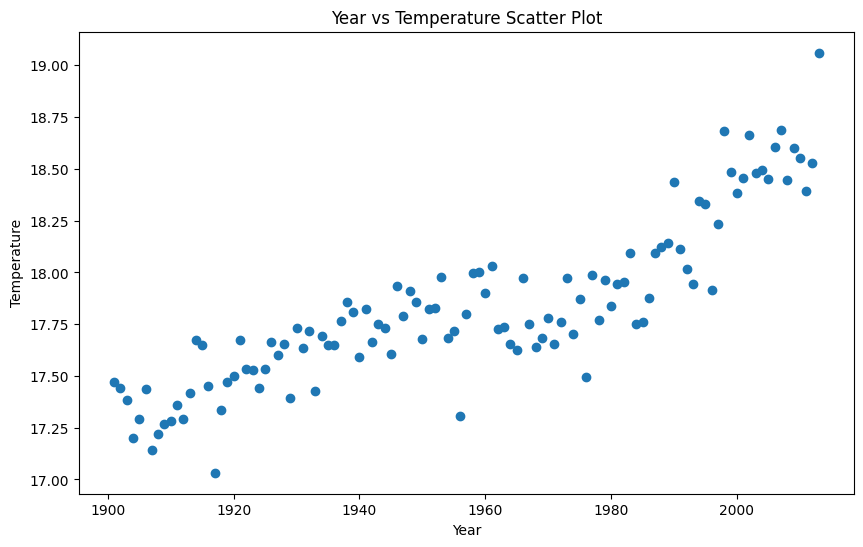

In [77]:
plt.figure(figsize=(10,6))

plt.scatter(yearly_temp['year'], yearly_temp['AverageTemperature'])

plt.title("Year vs Temperature Scatter Plot")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.savefig("outputs/plots/scatter_year_temp.png")
plt.show()

In [78]:
plt.scatter(df['CO2'], df['AverageTemperature'])

KeyError: 'CO2'

In [79]:
import os
print(os.listdir("outputs/plots"))

['heatmap.png', 'anomaly_plot.png', 'temp_trend.png', 'scatter_year_temp.png', 'forecast.png', 'rolling_avg.png']


In [80]:
from google.colab import files

files.download("outputs/plots/temp_trend.png")
files.download("outputs/plots/anomaly_plot.png")
files.download("outputs/plots/rolling_avg.png")
files.download("outputs/plots/forecast.png")
files.download("outputs/plots/heatmap.png")
files.download("outputs/plots/scatter_year_temp.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
df['dt'] = pd.to_datetime(df['dt'], errors='coerce')